### Get the data

In [1]:
import os
import pandas as pd
from datetime import datetime, timedelta, timezone
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed, ProcessPoolExecutor
from collections import defaultdict
import psutil
import hashlib
import logging
from typing import List, Tuple, Dict, Any
import time
from elasticsearch.helpers import bulk
import ipaddress


from helpers import timer
import helpers as hp

# Constants
INTERVAL_HOURS = 1
BATCH_SIZE = 1000
MAX_THREADS_MULTIPLIER = 2
DAYS_BACK = 1

# Configure logging
logging.basicConfig(level=logging.WARNING)  # Set to WARNING to reduce output
logger = logging.getLogger(__name__)

# Suppress elastic_transport logging
logging.getLogger('elastic_transport.transport').setLevel(logging.ERROR)  # Set to ERROR to reduce output

def adjust_date_by_days_now(days: int, fixed_date: datetime = datetime.now(timezone.utc)) -> str:
    """Adjusts the date by a given number of days."""
    adjusted_date_obj = fixed_date + timedelta(days=days)
    adjusted_date_str = adjusted_date_obj.strftime("%Y-%m-%dT%H:%M:%S.%fZ")[:-3] + "Z"
    return adjusted_date_str

def generate_time_ranges(start_time: str, end_time: str, interval_hours: int = INTERVAL_HOURS) -> List[Tuple[str, str]]:
    """Generates time ranges between start and end times."""
    start = datetime.strptime(start_time, "%Y-%m-%dT%H:%M:%S.%fZ")
    end = datetime.strptime(end_time, "%Y-%m-%dT%H:%M:%S.%fZ")
    ranges = [
        (
            (start + timedelta(hours=i)).strftime("%Y-%m-%dT%H:%M:%S.%f")[:-3] + "Z",
            (min(start + timedelta(hours=i + interval_hours), end)).strftime("%Y-%m-%dT%H:%M:%S.%f")[:-3] + "Z"
        )
        for i in range(0, int((end - start).total_seconds() // 3600) + 1, interval_hours)
    ]
    return ranges

def canonical_ipv6(addr_str: str) -> str:
    return ipaddress.IPv6Address(addr_str).compressed.lower()

def build_query_docs(start_time: str, end_time: str) -> Dict[str, Any]:
    """
    Build a query that matches all traceroute docs in [start_time, end_time)
    with ipv6=True. No aggregation—just return the fields we need.
    """
    return {
            "bool": {
                "must": [
                    {
                        "range": {
                            "timestamp": {
                                "gte":  start_time,
                                "lt":   end_time,
                                "format":"strict_date_optional_time"
                            }
                        }
                    },
                    {
                        "term": {
                            "ipv6": True
                        }
                    }
                ]
            }
        }

def query_and_scroll(start_time: str, end_time: str, batch_size: int = 1000) -> List[Dict[str, Any]]:
    """
    Scroll through every document matching build_query_docs(start_time, end_time),
    collecting all hits into a Python list of dicts. Uses a 2m scroll context.
    """
    query = build_query_docs(start_time, end_time)
    results = []

    # 1) Initial search with scroll
    initial = hp.es.search(
        index="ps_trace",
        query=query,
        scroll="2m",             # keep the scroll context alive for 2 minutes
        size=batch_size
    )

    scroll_id = initial["_scroll_id"]
    hits = initial["hits"]["hits"]

    # 2) Collect the first batch of hits
    for hit in hits:
        src = hit["_source"]
        if not src.get("ttls", []):
            break

        if not src.get("src", []):
            break

        if not src.get("dest", []):
            break

        if len(src.get("hops", []))<3:
            break

        results.append({
                "hops":          src.get("hops", []),
                "ttls":          src.get("ttls", []),
                "asns":          src.get("asns", []),
                "src_netsite_orig":   src.get("src_netsite", ""),
                "dest_netsite_orig":  src.get("dest_netsite", ""),
                "src_netsite":   src.get("src_netsite", "").upper(),
                "dest_netsite":  src.get("dest_netsite", "").upper(),
                "ipv6":          src.get("ipv6", False),
                "looping":          src.get("looping", False),
                "timestamp":     src.get("timestamp"),
                "path_complete": src.get("path_complete"),
                "destination_reached": src.get("destination_reached"),
                "route-sha1": src.get("route-sha1"),
                "dest_host": src.get("dest_host"),
                "src_host": src.get("src_host"),
                "dest": src.get("dest"),
                "src": src.get("src"),
                "path_len": len(src.get("hops", []))
            })


    # 3) Loop until no more hits
    while True:
        scroll_resp = hp.es.scroll(scroll_id=scroll_id, scroll="2m")
        hits = scroll_resp["hits"]["hits"]
        if not hits:
            break
        for hit in hits:
            src = hit["_source"]
            if not src.get("ttls", []):
                break

            if not src.get("src", []):
                break

            if not src.get("dest", []):
                break

            if len(src.get("hops", []))<3:
                break

            results.append({
                "hops":          src.get("hops", []),
                "ttls":          src.get("ttls", []),
                "asns":          src.get("asns", []),
                "src_netsite_orig":   src.get("src_netsite", ""),
                "dest_netsite_orig":  src.get("dest_netsite", ""),
                "src_netsite":   src.get("src_netsite", "").upper(),
                "dest_netsite":  src.get("dest_netsite", "").upper(),
                "ipv6":          src.get("ipv6", False),
                "looping":          src.get("looping", False),
                "timestamp":     src.get("timestamp"),
                "path_complete": src.get("path_complete"),
                "destination_reached": src.get("destination_reached"),
                "route-sha1": src.get("route-sha1"),
                "dest_host": src.get("dest_host"),
                "src_host": src.get("src_host"),
                "dest": src.get("dest"),
                "src": src.get("src"),
                "path_len": len(src.get("hops", []))
            })
        scroll_id = scroll_resp["_scroll_id"]

    # 4) Clear scroll context to free resources
    try:
        hp.es.clear_scroll(scroll_id=scroll_id)
    except Exception:
        pass

    return results

def parallel_querying_with_threads(time_ranges: List[Tuple[str, str]], max_threads: int) -> pd.DataFrame:
    """
    In parallel, run query_and_scroll over each (start,end) interval.
    Return a single DataFrame of all traceroute docs in all intervals.
    """
    all_results = []
    with tqdm(total=len(time_ranges), desc="Querying Time Ranges") as pbar:
        with ThreadPoolExecutor(max_workers=max_threads) as executor:
            future_to_range = {
                executor.submit(query_and_scroll, start, end): (start, end)
                for start, end in time_ranges
            }
            for future in as_completed(future_to_range):
                trange = future_to_range[future]
                try:
                    hits = future.result()
                    all_results.extend(hits)
                except Exception as exc:
                    print(f"Time range {trange} generated an exception: {exc}")
                finally:
                    pbar.update(1)

    # Build a DataFrame out of all collected hits
    df = pd.DataFrame(all_results)
    # Rename timestamp → dt for consistency (optional)
    df = df.rename(columns={"timestamp": "dt"})
    return df


num_cores = os.cpu_count()
print(num_cores)
max_threads = int((num_cores) * MAX_THREADS_MULTIPLIER)
start_date = '2025-04-10T14:00:01.837Z'
end_date = '2025-04-15T14:00:01.837Z'

time_ranges = generate_time_ranges(start_date, end_date, INTERVAL_HOURS)

odf = parallel_querying_with_threads(time_ranges, max_threads)

Success
48


Querying Time Ranges: 100%|██████████| 121/121 [03:31<00:00,  1.75s/it] 


### Compress the IPs

In [2]:
import ipaddress


def canonical_ipv6(addr_str: str) -> str:
    return ipaddress.IPv6Address(addr_str).compressed.lower()

def build_ipv6_map(df: pd.DataFrame) -> Dict[str, str]:

    all_ips = df["hops"].explode().dropna().unique()

    ipv6_map = {}
    for ip in all_ips:
        try:
            # ipaddress.IPv6Address().compressed    → compressed, no leading zeros
            # .lower() ensures consistent lowercase hex digits
            ipv6_map[ip] = canonical_ipv6(ip)
        except Exception:
            # In case some “hops” are malformed strings, just keep them unchanged:
            ipv6_map[ip] = ip.lower()
    return ipv6_map


def canonicalize_paths(df: pd.DataFrame,
                       ipv6_map: Dict[str, str]) -> pd.DataFrame:

    df.loc[:, "hops_compressed"] = df["hops"].apply(
        lambda hop_list: [ipv6_map.get(hop, hop.lower()) for hop in hop_list]
    )
    return df

df = odf.copy()
ipv6_map = build_ipv6_map(df)
df = canonicalize_paths(df, ipv6_map)

### Fix the mixed dates

In [3]:
import pandas as pd
import datetime

def parse_mixed_datetime(x):
    """
    Parse x that may be:
      - pd.Timestamp or datetime.datetime
      - a UNIX timestamp (int/float, in seconds)
      - a string in various common formats
    Returns a tz‐naive pd.Timestamp or NaT.
    """
    # 1) Already a Timestamp or datetime?
    if isinstance(x, pd.Timestamp):
        return x.tz_localize(None) if x.tzinfo else x
    if isinstance(x, datetime.datetime):
        return x.replace(tzinfo=None)

    # 2) Numeric → UNIX seconds
    if isinstance(x, (int, float)) and not pd.isna(x):
        return pd.to_datetime(x, unit='s', errors='coerce')

    # 3) String → try default parser first
    if isinstance(x, str):
        ts = pd.to_datetime(x, errors='coerce')  # infer is now default
        if pd.notna(ts):
            return ts
        # try explicit formats if needed
        for fmt in (
            "%Y-%m-%dT%H:%M:%SZ",   # e.g. 2025-05-02T04:00:00Z
            "%Y-%m-%d %H:%M:%S",    # e.g. 2025-05-02 04:00:00
            "%m/%d/%Y %H:%M",       # e.g. 05/02/2025 04:00
        ):
            try:
                return pd.to_datetime(x, format=fmt, errors='coerce')
            except Exception:
                pass
        return pd.NaT

    # everything else → NaT
    return pd.NaT

# Usage:
df['raw_dt']      = df['dt']                    # preserve original
df['dt_parsed']   = df['raw_dt'].apply(parse_mixed_datetime)

# How many failed?
n_fail = df['dt_parsed'].isna().sum()
print(f"{n_fail} rows failed to parse.")

df = df.dropna(subset=['dt_parsed'])            # drop unparseable rows
df['dt_parsed'] = pd.to_datetime(df['dt_parsed'], utc=True, errors='coerce')
df['dt_parsed'] = df['dt_parsed'].dt.tz_localize(None)

df['dt_bin'] = df['dt_parsed'].dt.floor('30T')


0 rows failed to parse.


### Get some basic stats about the paths

In [4]:
group_len_counts = df.groupby(['dt_bin', 'src', 'dest'])['path_len'].transform('nunique')

df['stable_paths'] = (group_len_counts == 1)


# Within a group, is the collective set of all observed TTLs contiguous?
def check_for_gaps(series_of_ttl_lists):
    # Flatten all TTL lists in the group into a single unique set
    all_ttls_in_group = set().union(*series_of_ttl_lists)
    if not all_ttls_in_group:
        return False # No TTLs, so no gaps
    # A set of TTLs has no gaps if its length equals its max value (assuming start is 1)
    return len(all_ttls_in_group) != max(all_ttls_in_group)


gaps_per_group = df.groupby(['dt_bin', 'src', 'dest'])['ttls'].apply(check_for_gaps)
gaps_per_group.name = 'has_ttl_gaps'

df = pd.merge(df, gaps_per_group, on=['dt_bin', 'src', 'dest'])


# For this, we need to associate each hop with its TTL.
# First, create a long DataFrame where each row is one hop with its TTL
hop_ttl_records = []
for _, row in df.iterrows():
    for i, hop in enumerate(row['hops']):
        # Use the actual TTL value from the 'ttls' list if available and aligned
        ttl = row['ttls'][i] if i < len(row['ttls']) else i + 1
        hop_ttl_records.append({
            'dt_bin': row['dt_bin'],
            'src': row['src'],
            'dest': row['dest'],
            'router': hop,
            'ttl': ttl
                    })
exploded_with_ttl_df = pd.DataFrame(hop_ttl_records)

# For each (group + router), count the number of unique TTLs it appeared at.
# If nunique is 1, its position was stable.
router_ttl_counts = exploded_with_ttl_df.groupby(['dt_bin', 'src', 'dest', 'router'])['ttl'].transform('nunique')
exploded_with_ttl_df['stable_position'] = (router_ttl_counts == 1)

path_counts = exploded_with_ttl_df.groupby(['dt_bin', 'src', 'dest', 'router']).size().reset_index(name='num_paths_present')
group_metrics = df[['dt_bin', 'src', 'dest', 'stable_paths', 'has_ttl_gaps']].drop_duplicates()
router_metrics = exploded_with_ttl_df[['dt_bin', 'src', 'dest', 'router', 'stable_position']].drop_duplicates()

agg_df = pd.merge(path_counts, group_metrics, on=['dt_bin', 'src', 'dest'])
agg_df = pd.merge(agg_df, router_metrics, on=['dt_bin', 'src', 'dest', 'router'])


### Check the set of IPs on the paths of a single source-destination pair


Randomly selected destination for heatmap: 2607:f8f0:690:3:0:0:127:40


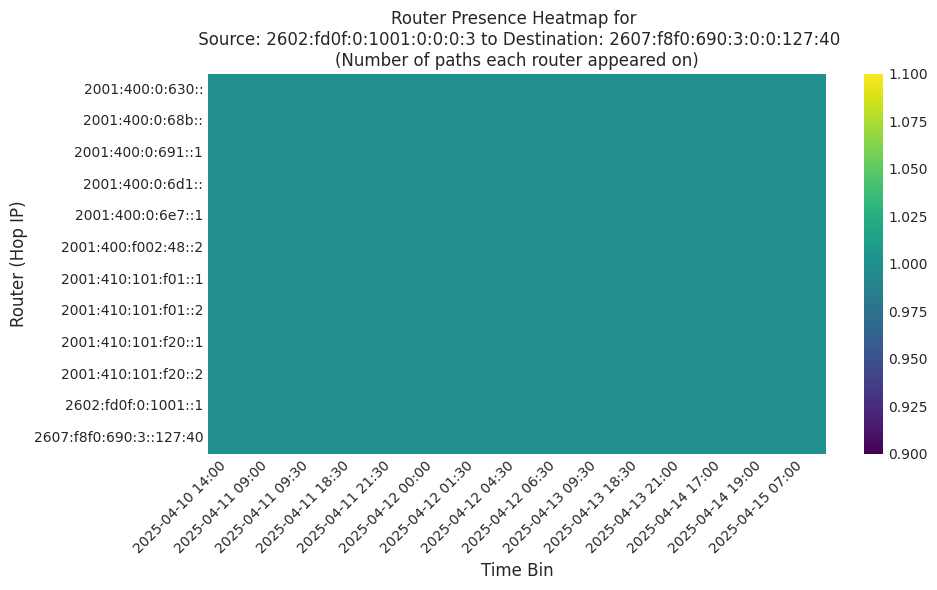

In [5]:
import random
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np
import seaborn as sns


unique_destinations = agg_df['dest'].unique()
selected_dest = random.choice(unique_destinations)
selected_src = random.choice(agg_df[agg_df['dest'] == selected_dest]['src'].unique())

print(f"\nRandomly selected destination for heatmap: {selected_dest}")

# Filter the aggregated data for the selected destination
heatmap_data = agg_df[(agg_df['dest'] == selected_dest) & (agg_df['src'] == selected_src)]

# Create a pivot table: Y-axis=router, X-axis=time, Z-axis(color)=count
heatmap_pivot = heatmap_data.pivot_table(
    index='router',
    columns='dt_bin',
    values='num_paths_present',
    fill_value=0  # Fill missing values with 0
)


plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6)) # Adjust size as needed

sns.heatmap(
    heatmap_pivot,
    ax=ax,
    cmap="viridis", # Use a color-friendly map
    # linewidths=.5,
    # annot=True, # Add the counts inside the cells
    # fmt="d" # Format annotations as integers
)

tick_locations = ax.get_xticks()
tick_labels = [
    heatmap_pivot.columns[int(loc)].strftime('%Y-%m-%d %H:%M')
    for loc in tick_locations if 0 <= loc < len(heatmap_pivot.columns)
]

ax.set_xticks(tick_locations)
ax.set_xticklabels(tick_labels, rotation=45, ha="right")

ax.set_title(f"Router Presence Heatmap for \n Source: {selected_src} to Destination: {selected_dest}\n(Number of paths each router appeared on)", fontsize=12)
ax.set_xlabel("Time Bin", fontsize=12)
ax.set_ylabel("Router (Hop IP)", fontsize=12)

plt.tight_layout()
plt.show()

### Insert 0s where the the paths have incomplete TTL sequences

In [6]:
def create_complete_path_and_ttls(row):
    hops = row['hops']
    asns = row['asns']
    ttls = row['ttls']

    # Handle empty or invalid data gracefully
    if not ttls:
        return ([], [])

    # Create a dictionary for quick lookups: {ttl: hop}
    ttl_to_hop_map = {ttl: hop for ttl, hop in zip(ttls, hops)}
    ttl_to_asn_map = {ttl: hop for ttl, hop in zip(ttls, asns)}

    # Determine the full range of TTLs for this path
    max_ttl = max(ttls)
    complete_ttls = list(range(1, max_ttl + 1))

    # Build the complete path, inserting '0' for missing hops
    complete_path = [ttl_to_hop_map.get(ttl, 0) for ttl in complete_ttls]
    complete_asns = [ttl_to_asn_map.get(ttl, 0) for ttl in complete_ttls]

    return complete_path, complete_ttls, complete_asns


# --- 2. Apply the function to the DataFrame to create the new columns ---

print("Generating 'complete_path' and 'complete_ttls' columns...")

# Apply the function. This creates a new Series where each item is a (path, ttls) tuple.
results_series = df.apply(create_complete_path_and_ttls, axis=1)

# Split the Series of tuples into two new columns
df[['complete_path', 'complete_ttls', 'complete_asns']] = pd.DataFrame(results_series.tolist(), index=df.index)
df.head()

Generating 'complete_path' and 'complete_ttls' columns...


,hops,ttls,asns,src_netsite_orig,dest_netsite_orig,src_netsite,dest_netsite,ipv6,looping,dt,...,path_len,hops_compressed,raw_dt,dt_parsed,dt_bin,stable_paths,has_ttl_gaps,complete_path,complete_ttls,complete_asns
0,"[2001:630:113::1, 2001:630:0:9001::3bd, 2001:6...","[1, 2, 3, 4, 5, 6, 7, 8, 9]","[786, 786, 786, 786, 786, 786, 786, 786, 786]",UKI-LT2-RHUL,UKI-SCOTGRID-GLASGOW,UKI-LT2-RHUL,UKI-SCOTGRID-GLASGOW,True,False,2025-04-12T18:55:14+00:00,...,9,"[2001:630:113::1, 2001:630:0:9001::3bd, 2001:6...",2025-04-12T18:55:14+00:00,2025-04-12 18:55:14,2025-04-12 18:30:00,True,False,"[2001:630:113::1, 2001:630:0:9001::3bd, 2001:6...","[1, 2, 3, 4, 5, 6, 7, 8, 9]","[786, 786, 786, 786, 786, 786, 786, 786, 786]"
1,"[2001:630:113::1, 2001:630:0:9001::3bd, 2001:6...","[1, 2, 3, 4, 5, 7]","[786, 786, 786, 786, 786, 786]",UKI-LT2-RHUL,,UKI-LT2-RHUL,,True,False,2025-04-12T18:58:36+00:00,...,6,"[2001:630:113::1, 2001:630:0:9001::3bd, 2001:6...",2025-04-12T18:58:36+00:00,2025-04-12 18:58:36,2025-04-12 18:30:00,True,True,"[2001:630:113::1, 2001:630:0:9001::3bd, 2001:6...","[1, 2, 3, 4, 5, 6, 7]","[786, 786, 786, 786, 786, 0, 786]"
2,"[2001:630:113::1, 2001:630:0:9001::3bd, 2001:6...","[1, 2, 3, 4, 5, 6, 7, 8]","[786, 786, 786, 786, 786, 786, 786, 786]",UKI-LT2-RHUL,UKI-SCOTGRID-DURHAM,UKI-LT2-RHUL,UKI-SCOTGRID-DURHAM,True,False,2025-04-12T18:57:32+00:00,...,8,"[2001:630:113::1, 2001:630:0:9001::3bd, 2001:6...",2025-04-12T18:57:32+00:00,2025-04-12 18:57:32,2025-04-12 18:30:00,True,False,"[2001:630:113::1, 2001:630:0:9001::3bd, 2001:6...","[1, 2, 3, 4, 5, 6, 7, 8]","[786, 786, 786, 786, 786, 786, 786, 786]"
3,"[2001:630:113::1, 2001:630:0:9001::3bd, 2001:6...","[1, 2, 3, 4, 5, 6, 7, 8, 9]","[786, 786, 786, 786, 786, 786, 786, 786, 786]",UKI-LT2-RHUL,UKI-SOUTHGRID-RALPP-LHCONE,UKI-LT2-RHUL,UKI-SOUTHGRID-RALPP-LHCONE,True,False,2025-04-12T18:57:04+00:00,...,9,"[2001:630:113::1, 2001:630:0:9001::3bd, 2001:6...",2025-04-12T18:57:04+00:00,2025-04-12 18:57:04,2025-04-12 18:30:00,True,False,"[2001:630:113::1, 2001:630:0:9001::3bd, 2001:6...","[1, 2, 3, 4, 5, 6, 7, 8, 9]","[786, 786, 786, 786, 786, 786, 786, 786, 786]"
4,"[2001:660:5009:9:193:48:99:100, 2001:1458:302:...","[1, 2, 5]","[2200, 513, 513]",IN2P3-CC-LHCOPNE,,IN2P3-CC-LHCOPNE,,True,False,2025-04-12T20:00:03+02:00,...,3,"[2001:660:5009:9:193:48:99:100, 2001:1458:302:...",2025-04-12T20:00:03+02:00,2025-04-12 18:00:03,2025-04-12 18:00:00,True,True,"[2001:660:5009:9:193:48:99:100, 2001:1458:302:...","[1, 2, 3, 4, 5]","[2200, 513, 0, 0, 513]"


### Fix the ASN paths through IP to ASN mapper

In [7]:
from tqdm import tqdm
import ipaddress
from collections import defaultdict


# Use a defaultdict with a set to handle cases where an IP might be seen with multiple ASNs
ip_to_asns_map = defaultdict(set)

for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Learning..."):
    for ip, asn in zip(row['complete_path'], row['complete_asns']):
        # We only learn from valid, existing mappings
        if ip != 0 and asn != 0:
            try:
                # Check if the IP is a private address
                ip_obj = ipaddress.ip_address(ip)
                if not ip_obj.is_private:
                    ip_to_asns_map[ip].add(asn)
            except ValueError:
                # Handle cases where the hop might not be a valid IP address string
                continue

print(f"Learned mappings for {len(ip_to_asns_map)} unique public IPs.")


# We will only use a mapping if we have only ever seen one ASN for a given IP.
ip_to_repaired_asn = {}
for ip, asns_set in ip_to_asns_map.items():
    if len(asns_set) == 1:
        # The .pop() method is a convenient way to get the single item from a set
        ip_to_repaired_asn[ip] = asns_set.pop()
    else: print(ip, asns_set)

print(f"Consolidated to {len(ip_to_repaired_asn)} high-confidence mappings for repairs.")


# --- Pass 2: Repair ASN Paths ---
print("\n--- Pass 2: Repairing incomplete ASN paths... ---")

repaired_paths_list = []
repaired_flags_list = []

for index, row in tqdm(df.iterrows(), total=df.shape[0], desc="Repairing..."):
    # Create a mutable copy of the original ASN path
    repaired_path = list(row['complete_asns'])
    was_repaired = False

    # Iterate through the path and repair missing ASNs (0)
    for i, asn in enumerate(repaired_path):
        if asn == 0:
            ip_at_position = row['complete_path'][i]

            # Check if it's a real IP and if we have a mapping for it
            if ip_at_position != 0 and ip_at_position in ip_to_repaired_asn:
                # Repair the path with the known ASN
                repaired_path[i] = ip_to_repaired_asn[ip_at_position]
                was_repaired = True

    repaired_paths_list.append(repaired_path)
    repaired_flags_list.append(was_repaired)

# --- Add new columns to the DataFrame ---
df['repaired_asns'] = repaired_paths_list
df['is_repaired'] = repaired_flags_list

print("\nRepair process complete.")

# --- Display Results ---
print("\n--- Value Counts for 'is_repaired' flag ---")
print(df['is_repaired'].value_counts())

print("\n--- Sample of Repaired Paths ---")
# Show a sample of rows that were successfully repaired
print(df[df['is_repaired'] == True][[
    'complete_asns', 
    'repaired_asns', 
    'is_repaired'
]].head())

Learning...: 100%|██████████| 87715/87715 [00:25<00:00, 3457.74it/s]


Learned mappings for 1563 unique public IPs.
2a00:139c:0:20::b {58069, 34878}
2a00:139c:5:585:0:41:2:6 {58069, 34878}
2a00:139c:5:585:0:41:2:12 {58069, 34878}
2a00:139c:5:585::3 {58069, 34878}
2a00:139c:5:693:0:43:1:8e {58069, 34878}
2a00:139c:0:8::2 {58069, 34878}
2a00:139c:0:8100::4 {58069, 34878}
2a00:139c:0:1::2 {58069, 34878}
2a00:139c:0:c::2 {58069, 34878}
2a00:139c:5:693::3 {58069, 34878}
2a00:139c:0:c::1 {58069, 34878}
2a00:139c:0:25::2 {58069, 34878}
Consolidated to 1551 high-confidence mappings for repairs.

--- Pass 2: Repairing incomplete ASN paths... ---


Repairing...: 100%|██████████| 87715/87715 [00:09<00:00, 9084.01it/s] 


Repair process complete.

--- Value Counts for 'is_repaired' flag ---
is_repaired
False    87273
True       442
Name: count, dtype: int64

--- Sample of Repaired Paths ---
                                         complete_asns  \
49       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]   
449               [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]   
453   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]   
742  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
786      [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]   

                                         repaired_asns  is_repaired  
49   [0, 293, 293, 293, 293, 293, 20965, 20965, 209...         True  
449  [7212, 293, 293, 0, 0, 11096, 0, 0, 0, 0, 6356...         True  
453  [7212, 293, 293, 293, 293, 20965, 20965, 0, 0,...         True  
742  [7212, 7212, 0, 10490, 10490, 0, 0, 0, 0, 0, 0...         True  
786  [0, 7212, 0, 10490, 0, 0, 0, 0, 0, 20965, 2096...         True  


### Analyze each pair's paths. Compare each 2 routes and define routing events

In [8]:
from tqdm import tqdm
import editdistance


events_list = []
df = df.sort_values(['src', 'dest', 'dt_parsed']).reset_index(drop=True)

grouped = df.groupby(['src', 'dest'])

for (src, dest), group in tqdm(grouped, total=len(grouped), desc="Processing Paths"):
    last_seen_path = []
    last_seen_asns = []
    last_dest_reached = None

    for index, row in group.iterrows():
        current_path = row['complete_path']
        current_asns = row['repaired_asns']
        dest_reached = row['destination_reached']
        is_repaired = row['is_repaired']

        if last_dest_reached is None:
            last_seen_path, last_seen_asns, last_dest_reached = current_path, current_asns, dest_reached
            continue


        # 1. Ignore change if destination reachability has flipped
        if dest_reached != last_dest_reached:
            last_seen_path, last_seen_asns, last_dest_reached = current_path, current_asns, dest_reached
            continue

        # 2. Ignore if paths are identical
        if last_seen_path == current_path:
            last_seen_path, last_seen_asns, last_dest_reached = current_path, current_asns, dest_reached
            continue

        # 3. Ignore if the only change is a single repeated hop at the end
        is_terminal_repeat = False
        if len(current_path) == len(last_seen_path) + 1 and current_path[:-1] == last_seen_path and current_path[-1] == current_path[-2]:
            is_terminal_repeat = True
        elif len(last_seen_path) == len(current_path) + 1 and last_seen_path[:-1] == current_path and last_seen_path[-1] == last_seen_path[-2]:
            is_terminal_repeat = True
        if is_terminal_repeat:
            last_seen_path, last_seen_asns, last_dest_reached = current_path, current_asns, dest_reached
            continue


        last_set = set(last_seen_path) - {0}; current_set = set(current_path) - {0}
        jaccard_similarity = len(last_set.intersection(current_set)) / len(last_set.union(current_set)) if len(last_set.union(current_set)) > 0 else 0
        edit_dist = editdistance.eval(last_seen_path, current_path)
        last_asn_set = set(last_seen_asns) - {0}; current_asn_set = set(current_asns) - {0}
        asn_jaccard_similarity = len(last_asn_set.intersection(current_asn_set)) / len(last_asn_set.union(current_asn_set)) if len(last_asn_set.union(current_asn_set)) > 0 else 0
        asn_edit_distance = editdistance.eval(last_seen_asns, current_asns)

        prefix_len, suffix_len = 0, 0
        for i in range(min(len(last_seen_path), len(current_path))):
            if last_seen_path[i] == current_path[i]: prefix_len += 1
            else: break
        for i in range(1, min(len(last_seen_path), len(current_path)) - prefix_len + 1):
            if last_seen_path[-i] == current_path[-i]: suffix_len += 1
            else: break
        last_segment = last_seen_path[prefix_len : len(last_seen_path) - suffix_len]
        current_segment = current_path[prefix_len : len(current_path) - suffix_len]

        event_type = 'Unknown'
        previous_hops_final, new_hops_final = last_segment, current_segment

        # Perform the "diff" for segment changes
        last_segment_set = set(h for h in last_segment if h != 0)
        current_segment_set = set(h for h in current_segment if h != 0)
        previous_hops_final = sorted(list(last_segment_set - current_segment_set))
        new_hops_final = sorted(list(current_segment_set - last_segment_set))

        last_segment_valid_hops = set(h for h in last_segment if h != 0)
        current_segment_valid_hops = set(h for h in current_segment if h != 0)


        # 1. Unresponsive Hop: Hops that were previously responsive (not 0) are now all unresponsive (0).
        if len(last_segment_valid_hops) > 0 and len(current_segment_valid_hops) == 0:
          event_type = 'Unresponsive Hop'

        # 2. Restored Hop: Hops that were previously all unresponsive (0) are now responsive.
        elif len(last_segment_valid_hops) == 0 and len(current_segment_valid_hops) > 0:
          event_type = 'Restored Hop'

        # 3. Load Balancing: High path similarity but with specific changes.
        elif ((jaccard_similarity < 1 and jaccard_similarity > 0.5) \
            and edit_dist > 0 and len(new_hops_final) + len(previous_hops_final) > 2) \
            or \
            (len(last_segment) == 1 and len(current_segment) == 1 and \
             last_segment[0] != 0 and current_segment[0] != 0 and asn_jaccard_similarity == 1):
          event_type = 'Load Balancing'

        # 4. Segment Change: A contained change in the middle of the path.
        elif prefix_len >= 2 and suffix_len >= 1 and (any(h != 0 for h in last_segment) or any(h != 0 for h in current_segment)) and jaccard_similarity < 1:
          event_type = 'Segment Change'

        # 5. Major Rerouting: Low path and ASN similarity, indicating a significant path change.
        elif jaccard_similarity < 1 and edit_dist > 0 and asn_edit_distance > 0 and asn_jaccard_similarity < 1:
          event_type = 'Major Rerouting'

        # if event_type != 'Unknown':
        events_list.append({
            'timestamp': row['dt_parsed'], 'src': src, 'dest': dest, 'event_type': event_type,
            'jaccard_similarity': round(jaccard_similarity, 2), 'edit_distance': edit_dist,
            'asn_jaccard_similarity': round(asn_jaccard_similarity, 2), 'asn_edit_distance': asn_edit_distance,
            'ttl': prefix_len + 1, 'previous_hop': previous_hops_final, 'new_hop': new_hops_final,
            'df_index': index, 'dest_reached': dest_reached, 'is_repaired': is_repaired
        })

        last_seen_path, last_seen_asns, last_dest_reached = current_path, current_asns, dest_reached

events_df = pd.DataFrame(events_list)
print("\nEvent detection complete. Found the following event types:")
print(events_df['event_type'].value_counts())

Processing Paths: 100%|██████████| 6408/6408 [00:15<00:00, 405.32it/s]



Event detection complete. Found the following event types:
event_type
Load Balancing      29412
Unknown             10693
Segment Change       8367
Restored Hop         2662
Unresponsive Hop     2524
Major Rerouting      1530
Name: count, dtype: int64


### Build some plots

In [9]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import colormaps
import numpy as np



def draw_ip_path_on_ax(ax, path_before, path_after, event_details):
    all_ips_in_order = sorted(list(set(h for h in path_before + path_after if h != 0)),
                              key=lambda ip: (path_before + path_after).index(ip))
    ip_to_id = {ip: f"h{i+1}" for i, ip in enumerate(all_ips_in_order)}

    n = len(ip_to_id)
    if n > 0:
        cmap = colormaps['tab20b']
        id_to_color = {id_str: cmap(i / (n - 1) if n > 1 else 0.5) for i, id_str in enumerate(ip_to_id.values())}
    else:
        id_to_color = {}

    G = nx.DiGraph()

    prev_hops = event_details.get('previous_hop', [])
    new_hops = event_details.get('new_hop', [])
    prev_hops_set = set(prev_hops if isinstance(prev_hops, list) else [prev_hops])
    new_hops_set = set(new_hops if isinstance(new_hops, list) else [new_hops])

    previous_hop_ids = {ip_to_id.get(h) for h in prev_hops_set if h is not None}
    new_hop_ids = {ip_to_id.get(h) for h in new_hops_set if h is not None}
    event_ids = previous_hop_ids | new_hop_ids

    for y_offset, path, path_label, edge_color, line_style in [
        (0.2, path_before, 'Before:', 'dimgray', 'dashed'),
        (-0.2, path_after, 'After:', 'black', 'solid')
    ]:
        nodes_to_draw = [{'key': f"node_{i}_{y_offset}", 'pos': (i, y_offset), 'hop': hop} for i, hop in enumerate(path)]
        pos_map = {n['key']: n['pos'] for n in nodes_to_draw}
        node_keys = [n['key'] for n in nodes_to_draw]
        real_nodes = [n for n in nodes_to_draw if n['hop'] != 0]
        placeholder_nodes = [n for n in nodes_to_draw if n['hop'] == 0]

        real_node_ids = [ip_to_id[n['hop']] for n in real_nodes]
        fill_colors = [id_to_color[id] for id in real_node_ids]


        border_colors = ['red' if hid in event_ids else 'black' for hid in real_node_ids]
        border_widths = [3.0 if hid in event_ids else 1.0 for hid in real_node_ids]

        nx.draw_networkx_nodes(G, pos_map, nodelist=[n['key'] for n in real_nodes], node_color=fill_colors,
                               edgecolors=border_colors, linewidths=border_widths, node_size=1200, ax=ax)
        nx.draw_networkx_nodes(G, pos_map, nodelist=[n['key'] for n in placeholder_nodes], node_color='lightgray',
                               node_shape='s', node_size=800, edgecolors='gray', ax=ax)
        nx.draw_networkx_edges(G, pos_map, edgelist=[(node_keys[i], node_keys[i+1]) for i in range(len(node_keys)-1)],
                               edge_color=edge_color, style=line_style, width=1.5, arrowsize=20, ax=ax)
        nx.draw_networkx_labels(G, pos_map, labels={n['key']: ip_to_id[n['hop']] for n in real_nodes},
                                font_size=9, font_color='white', font_weight='bold', ax=ax)
        nx.draw_networkx_labels(G, pos_map, labels={n['key']: '*' for n in placeholder_nodes},
                                font_size=11, font_color='black', font_weight='bold', ax=ax)
        ax.text(-0.5, y_offset, path_label, fontsize=12, fontweight='bold', ha='right', va='center')

    ax.set_title("IP Hop Path", fontsize=14)
    ax.set_ylim(-0.7, 0.7)
    return ip_to_id


def draw_as_path_on_ax(ax, asns_before, asns_after, event_details):
    """Draws the ASN path comparison, highlighting entire segments."""

    as_path_before_comp = asns_before
    as_path_after_comp = asns_after

    all_asns = sorted(list(set(a for a in as_path_before_comp + as_path_after_comp)))

    n = len(all_asns)
    if n > 0:
        cmap = colormaps['Pastel2']
        asn_to_color = {asn: cmap(i / (n - 1) if n > 1 else 0.5) for i, asn in enumerate(all_asns)}
        print(all_asns)
    else:
        asn_to_color = {}
    # asn_to_color[0] = 'black'

    prev_asns = event_details.get('previous_asn', [])
    new_asns = event_details.get('new_asn', [])
    prev_asns_set = set(prev_asns if isinstance(prev_asns, list) else [prev_asns])
    new_asns_set = set(new_asns if isinstance(new_asns, list) else [new_asns])
    event_asns = prev_asns_set | new_asns_set

    G = nx.DiGraph()
    for y_offset, path, path_label, edge_color, line_style in [
        (0.2, as_path_before_comp, 'Before:', 'dimgray', 'dashed'),
        (-0.2, as_path_after_comp, 'After:', 'black', 'solid')
    ]:
        nodes_to_draw = [{'key': f"asn_{i}_{y_offset}", 'pos': (i, y_offset), 'asn': asn} for i, asn in enumerate(path)]
        pos_map = {n['key']: n['pos'] for n in nodes_to_draw}

        border_colors = ['dimgray' for n in nodes_to_draw]
        border_widths = [1.0 for n in nodes_to_draw]

        nx.draw_networkx_nodes(G, pos_map, nodelist=[n['key'] for n in nodes_to_draw],
                               node_color=[asn_to_color.get(n['asn'], 'white') for n in nodes_to_draw],
                               edgecolors=border_colors, linewidths=border_widths, node_shape='s', node_size=1800, ax=ax)
        nx.draw_networkx_edges(G, pos_map, edgelist=[(nodes_to_draw[i]['key'], nodes_to_draw[i+1]['key']) for i in range(len(nodes_to_draw)-1)],
                               edge_color=edge_color, style=line_style, width=1.5, arrowsize=20, ax=ax)
        nx.draw_networkx_labels(G, pos_map, labels={n['key']: str(n['asn']) if n['asn'] != 0 else '*' for n in nodes_to_draw},
                                font_size=9, font_weight='bold', font_color='black', ax=ax)
        ax.text(-0.5, y_offset, path_label, fontsize=12, fontweight='bold', ha='right', va='center')

    ax.set_title("AS Path", fontsize=14)
    ax.set_ylim(-0.7, 0.7)


def visualize_event_side_by_side(event, path_before_row, path_after_row,  event_type):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 9), gridspec_kw={'hspace': 0.4})


    event_for_viz = event.copy()
    prev_hops = event['previous_hop']
    if isinstance(prev_hops, list):
        start_ttl_index = event['ttl'] - 1
        prev_segment_len = len(prev_hops)
        event_for_viz['previous_asn'] = path_before_row['complete_asns'][start_ttl_index : start_ttl_index + prev_segment_len]
    else: # It's a single hop event
        ttl_index = event['ttl'] - 1
        event_for_viz['previous_asn'] = path_before_row['complete_asns'][ttl_index] if ttl_index < len(path_before_row['complete_asns']) else 0

    # Process new_hop to get new_asn
    new_hops = event['new_hop']
    if isinstance(new_hops, list):
        start_ttl_index = event['ttl'] - 1
        new_segment_len = len(new_hops)
        event_for_viz['new_asn'] = path_after_row['complete_asns'][start_ttl_index : start_ttl_index + new_segment_len]
    else: # Single hop event
        ttl_index = event['ttl'] - 1
        event_for_viz['new_asn'] = path_after_row['complete_asns'][ttl_index] if ttl_index < len(path_after_row['complete_asns']) else 0

    # --- Draw Plots ---
    ip_to_id = draw_ip_path_on_ax(ax1, path_before_row['complete_path'], path_after_row['complete_path'], event_for_viz)
    draw_as_path_on_ax(ax2, path_before_row['complete_asns'], path_after_row['complete_asns'], event_for_viz)

    # --- Print Legend ---
    print("\n" + "="*50 + "\nLEGEND FOR THE VISUALIZATION ABOVE\n" + "="*50)
    print("\n--- Hop ID to IP Address Mapping ---")
    for id_val, ip in ip_to_id.items():
        print(f"  {id_val}: {ip}")
    print("\n" + "="*50)

    fig.suptitle(f"Event Type: {event_type}", fontsize=18, y=0.98)
    plt.show()

### Plot

,timestamp,src,dest,event_type,jaccard_similarity,edit_distance,asn_jaccard_similarity,asn_edit_distance,ttl,previous_hop,new_hop,df_index,dest_reached,is_repaired
7230,2025-04-14 19:33:03,2001:4118:900:cc00:0:0:0:125,2001:630:80:2fd:0:0:aaff:59f0,Load Balancing,0.6,7,1.0,2,4,"[2001:630:0:10::1f2, 2001:630:80:fff::17a, 200...","[2001:4118:0:81::2, 2001:630:0:10::46, 2001:63...",8440,False,False


[786, 2607, 20965]

LEGEND FOR THE VISUALIZATION ABOVE

--- Hop ID to IP Address Mapping ---
  2001:4118:900:cc00::1: h1
  2001:4118:200:e3c::1: h2
  2001:4118::1: h3
  2001:798:99:1::49: h4
  2001:798:cc:1::10e: h5
  2001:798:cc:1::cd: h6
  2001:798:cc::21: h7
  2001:798:cc::26: h8
  2001:798:cc:1::2a: h9
  2001:798:99:1::7e: h10
  2001:630:0:10::1de: h11
  2001:630:0:10::1f2: h12
  2001:630:0:100e:10::1e: h13
  2001:630:80:fff::17a: h14
  2001:630:80:2fd::aaff:59f0: h15
  2001:4118:0:81::2: h16
  2001:798:cc:1::11d: h17
  2001:630:0:10::46: h18
  2001:630:0:9011::4ef: h19
  2001:630:80:fff::17b: h20



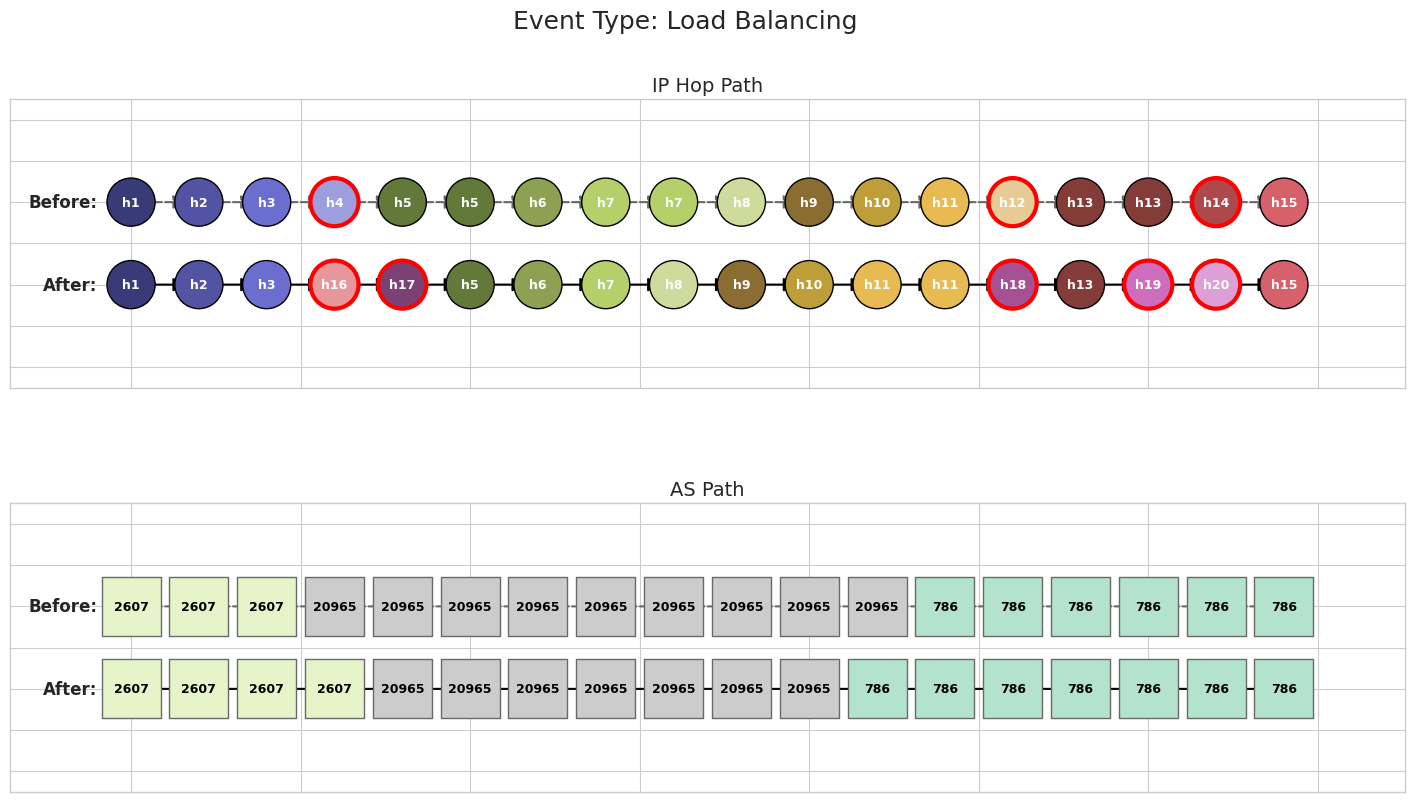

,timestamp,src,dest,event_type,jaccard_similarity,edit_distance,asn_jaccard_similarity,asn_edit_distance,ttl,previous_hop,new_hop,df_index,dest_reached,is_repaired
7620,2025-04-10 21:04:12,2001:4118:900:cc00:0:0:0:125,2001:67c:1bec:f069:0:0:0:75,Segment Change,0.43,6,1.0,1,3,"[2001:4118:0:81::2, 2001:4118::2, 2001:798:cc:...","[2001:4118::1, 2001:798:99:1::49, 2001:798:cc:...",8857,False,False


[2607, 20965, 59624]

LEGEND FOR THE VISUALIZATION ABOVE

--- Hop ID to IP Address Mapping ---
  2001:4118:900:cc00::1: h1
  2001:4118:200:e3c::1: h2
  2001:4118::2: h3
  2001:4118:0:81::2: h4
  2001:798:cc:1::11d: h5
  2001:798:cc:1::cd: h6
  2001:798:cc::21: h7
  2001:798:cc::61: h8
  2001:67c:1bec::a:163: h9
  2001:67c:1bec:fa49::9: h10
  2001:4118::1: h11
  2001:798:99:1::49: h12
  2001:798:cc:1::10e: h13
  2001:798:cc:1::c5: h14



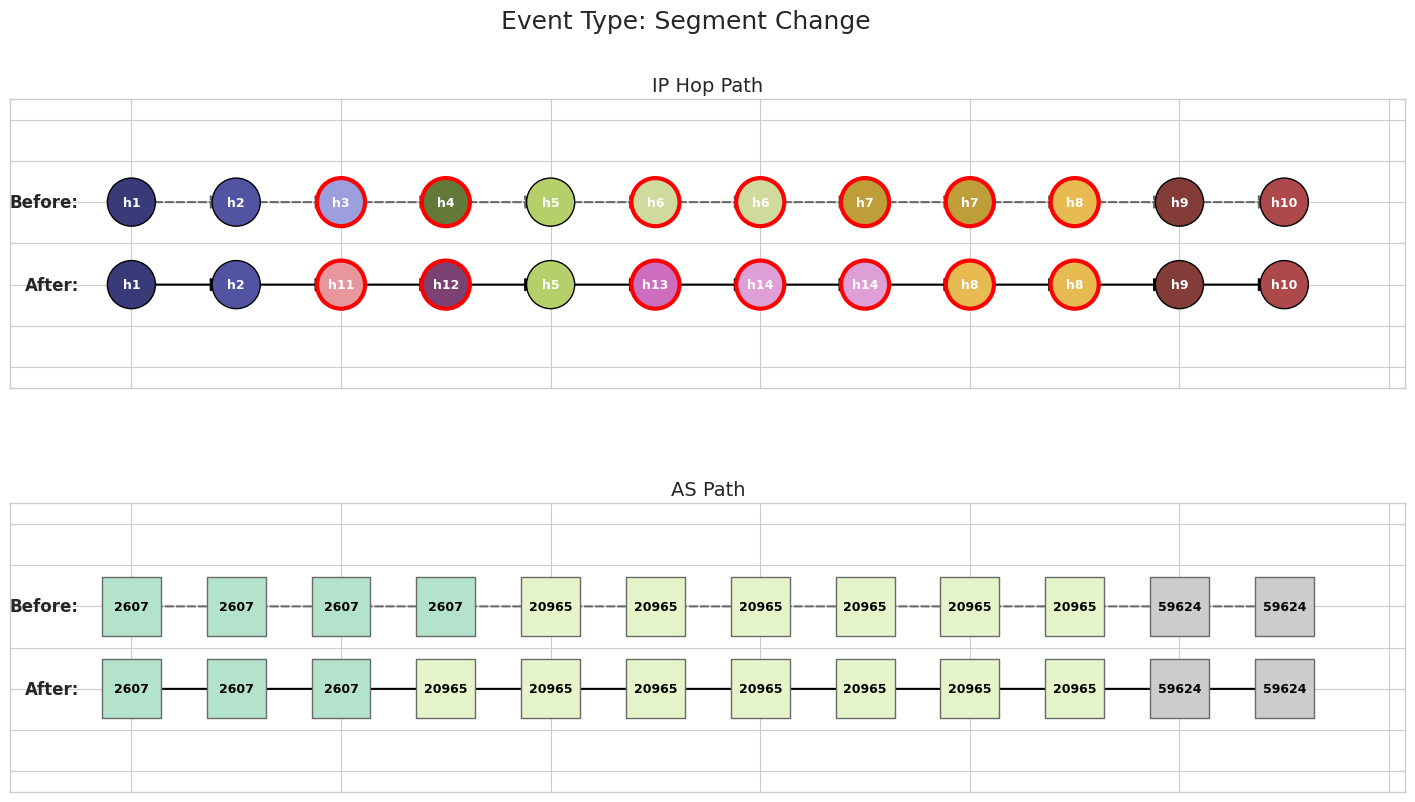

,timestamp,src,dest,event_type,jaccard_similarity,edit_distance,asn_jaccard_similarity,asn_edit_distance,ttl,previous_hop,new_hop,df_index,dest_reached,is_repaired
50290,2025-04-14 06:40:46,2a05:81c5:301:228:0:0:0:e597,2001:660:302c:23:134:158:132:200,Restored Hop,0.94,1,1.0,1,7,[],[2001:798:cc::62],79714,True,False


[0, 2200, 2875, 20965, 59624]

LEGEND FOR THE VISUALIZATION ABOVE

--- Hop ID to IP Address Mapping ---
  2a05:81c5:301:228::1: h1
  2a05:81c5:4:7::133: h2
  2a05:81c5:4:7::132: h3
  2001:67c:1bec::a:151: h4
  2001:67c:1bec::a:150: h5
  2001:798:99:1::8d: h6
  2001:798:cc::26: h7
  2001:798:cc:1::2a: h8
  2001:798:cc:1::ba: h9
  2001:798:cc::75: h10
  2001:798:18:10aa::2: h11
  2001:660:7903:6000:1::131: h12
  2001:660:7904:142:1::2: h13
  2001:660:302c::3:1: h14
  2001:660:302c:23:134:158:132:200: h15
  2001:798:cc::62: h16



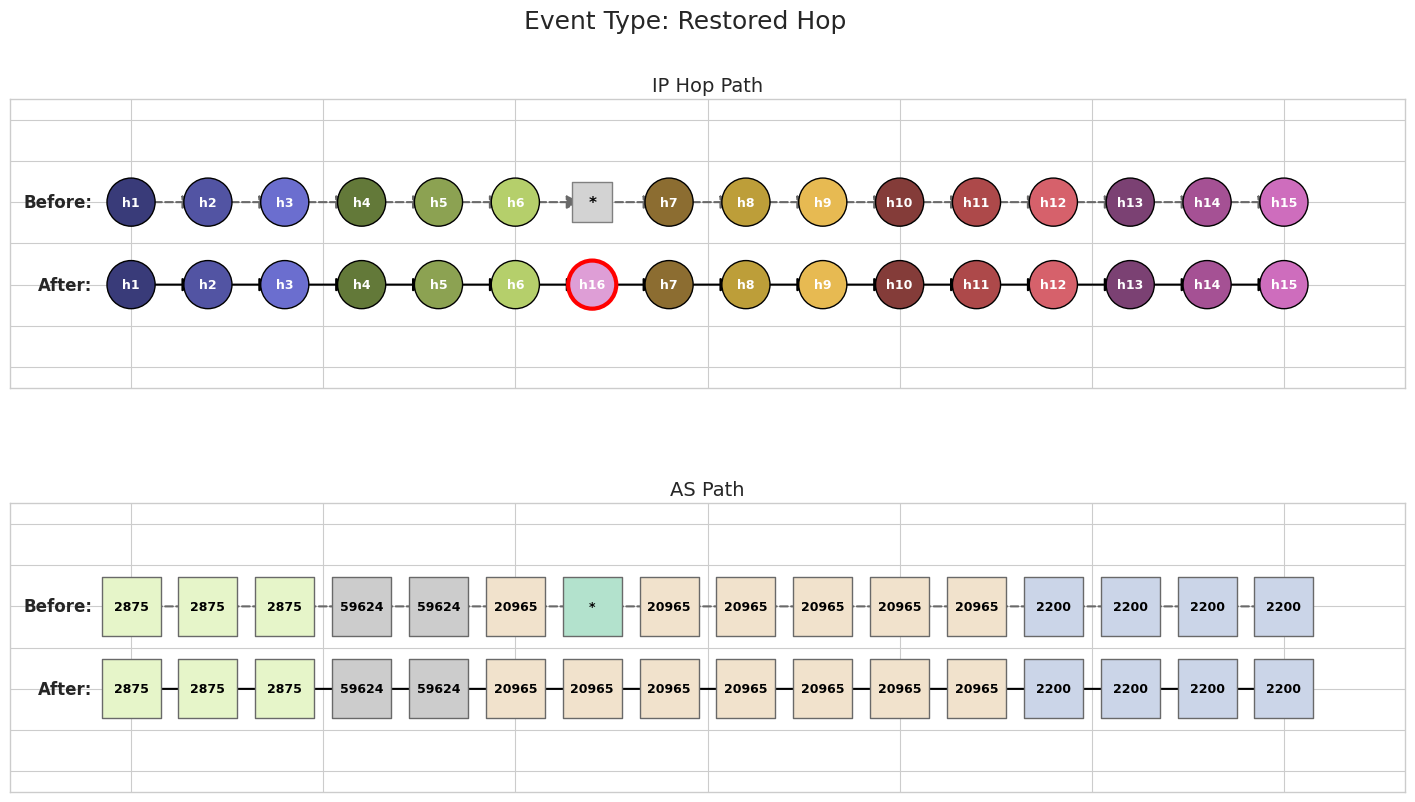

,timestamp,src,dest,event_type,jaccard_similarity,edit_distance,asn_jaccard_similarity,asn_edit_distance,ttl,previous_hop,new_hop,df_index,dest_reached,is_repaired
34471,2025-04-14 04:21:52,2001:718:401:6025:1:0:0:192,2001:630:58:1820:0:0:82f6:b06d,Unresponsive Hop,0.92,1,1.0,1,3,[2001:718:1e00:1::2],[],51290,False,False


[0, 786, 2852, 20965]

LEGEND FOR THE VISUALIZATION ABOVE

--- Hop ID to IP Address Mapping ---
  2001:718:401:6025::1: h1
  2001:718:409:6::31: h2
  2001:718:1e00:1::2: h3
  2001:798:13:10aa::1: h4
  2001:798:cc::81: h5
  2001:798:cc:1::c5: h6
  2001:798:cc::21: h7
  2001:798:cc::26: h8
  2001:798:cc:1::2a: h9
  2001:798:99:1::7e: h10
  2001:630:0:8042::906: h11
  2001:630:58:1000::10: h12
  2001:630:58:1080:2::1: h13



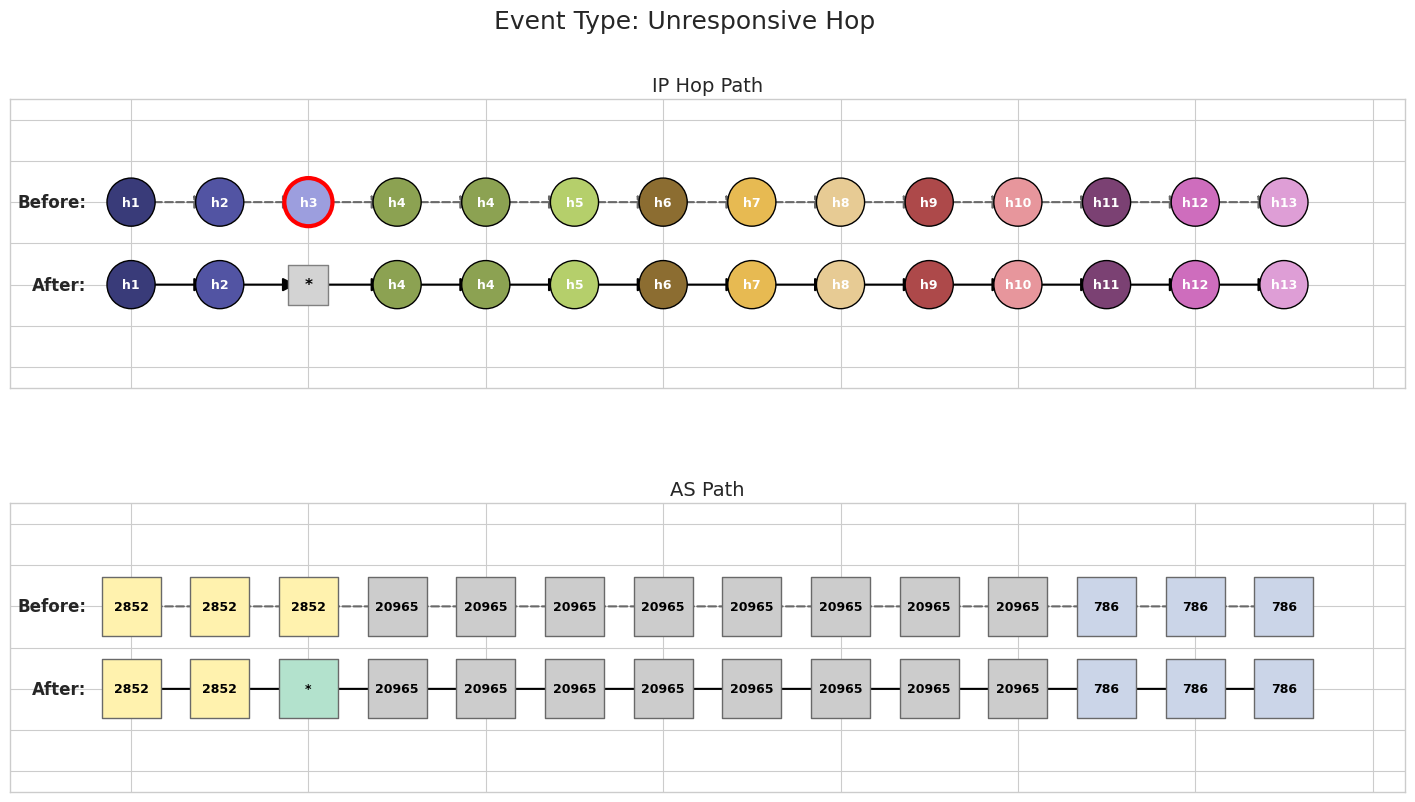

,timestamp,src,dest,event_type,jaccard_similarity,edit_distance,asn_jaccard_similarity,asn_edit_distance,ttl,previous_hop,new_hop,df_index,dest_reached,is_repaired
4730,2025-04-11 18:25:25,2001:320:15:125:a1:da:ec:1002,2620:0:210:1:0:0:0:17,Unknown,0.5,4,1.0,3,2,"[2001:1458:302:29::1, ::ffff:169:254:165:1, fd...",[2001:320:11:102::1],5708,False,False


[0, 513, 1237]

LEGEND FOR THE VISUALIZATION ABOVE

--- Hop ID to IP Address Mapping ---
  2001:320:15:125::3: h1
  ::ffff:169:254:165:1: h2
  2001:1458:302:29::1: h3
  2001:1458:302:20::2: h4
  fddd:7d33:c9b4:ff::26: h5
  2001:320:11:102::1: h6



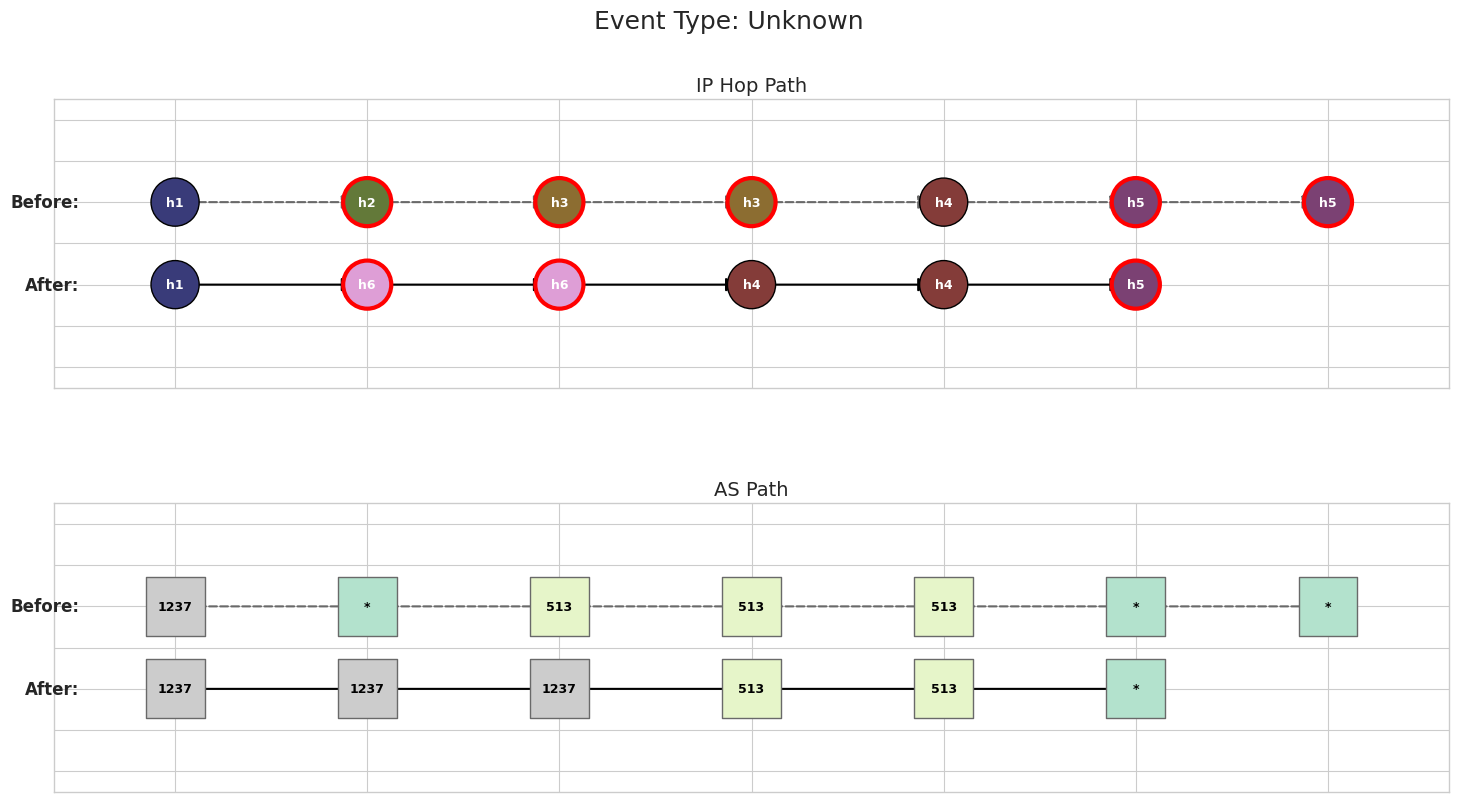

,timestamp,src,dest,event_type,jaccard_similarity,edit_distance,asn_jaccard_similarity,asn_edit_distance,ttl,previous_hop,new_hop,df_index,dest_reached,is_repaired
31326,2025-04-13 10:22:57,2001:67c:1148:203:0:0:0:242,2001:48a8:68f7:1:192:41:230:60,Major Rerouting,0.33,7,0.8,2,1,"[2001:400:0:633::1, 2001:400:0:655::, 2001:400...","[2001:400:0:668::, 2001:400:0:6bb::1, 2001:400...",44845,False,False


[0, 229, 293, 766, 20965, 43115]

LEGEND FOR THE VISUALIZATION ABOVE

--- Hop ID to IP Address Mapping ---
  2001:67c:1148:203::254: h1
  2001:720:1500::5: h2
  2001:798:111:1::39: h3
  2001:798:cc:1::96: h4
  2001:798:111:1::61: h5
  2001:798:111:1::2e: h6
  2001:400:0:664::: h7
  2001:400:0:698::1: h8
  2001:400:0:655::: h9
  2001:400:0:6c2::1: h10
  2001:400:0:633::1: h11
  2001:400:f002:38::6: h12
  2001:67c:1148:203::253: h13
  2001:400:0:6bb::1: h14
  2001:400:0:668::: h15
  2001:400:0:707::1: h16
  2001:400:f002:38::5: h17
  2001:48a8:68f7:ff03::1: h18



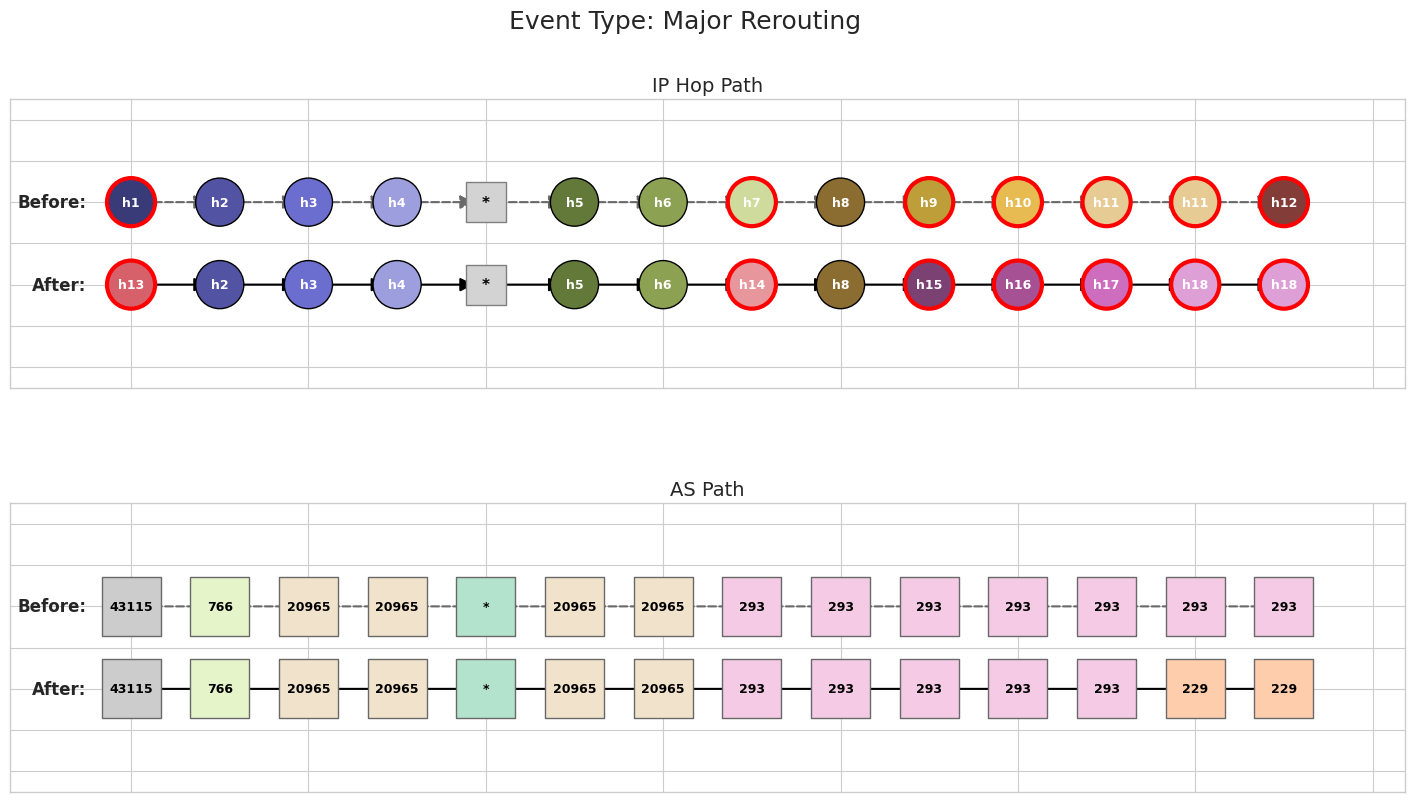

In [10]:
event_types_to_visualize = events_df['event_type'].unique()
for event_type in event_types_to_visualize:
    events = events_df[(events_df['event_type'] == event_type)]

    if not events.empty:
        event_to_show = events.sample(1)
        display(event_to_show)
        event_to_show = event_to_show.iloc[0]
        visualize_event_side_by_side(
            event=event_to_show,
            path_before_row=df.iloc[event_to_show['df_index'] - 1],
            path_after_row=df.iloc[event_to_show['df_index']],
            event_type = event_type
        )